In [65]:
import brainsss
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster
from scipy.cluster import hierarchy
from scipy.signal import butter, filtfilt, freqz
from scipy import signal
import matplotlib as mpl
from matplotlib.pyplot import cm
import random
from scipy.stats import sem, zscore, mode
import time
import h5py
import ants
import nibabel as nib
import matplotlib
from scipy.ndimage import gaussian_filter1d
import pickle
from skimage import io
import glob
from scipy.optimize import curve_fit
from sklearn.mixture import GaussianMixture
from brokenaxes import brokenaxes
from sklearn.cluster import KMeans
import seaborn as sns

In [66]:
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later'
save_dir=os.path.join(later_dir,'temp_filter','figs')

In [67]:
for x in sorted(os.listdir(later_dir)):
    if 'dic' in x:
        print(x)

10flies_5sec_event_times_split_dic.pkl
10flies_best_event_times_split_dic.pkl
10flies_event_times_split_dic.pkl
10flies_total_dict.pkl
10flies_trial_type_dic.pkl
226_1793340_individual_clusters_ch_2_dict.pkl
226_individual_clusters_ch_2_after_dict.pkl
226_individual_clusters_ch_2_dict.pkl
227_individual_clusters_ch_2_after_dict.pkl
227_individual_clusters_ch_2_dict.pkl
228_individual_clusters_ch_2_after_dict.pkl
228_individual_clusters_ch_2_dict.pkl
234_individual_clusters_ch_2_after_dict.pkl
234_individual_clusters_ch_2_dict.pkl
239_individual_clusters_ch_2_after_dict.pkl
239_individual_clusters_ch_2_dict.pkl
240_individual_clusters_ch_2_after_dict.pkl
240_individual_clusters_ch_2_dict.pkl
241_individual_clusters_ch_2_after_dict.pkl
241_individual_clusters_ch_2_dict.pkl
242_individual_clusters_ch_2_after_dict.pkl
242_individual_clusters_ch_2_dict.pkl
249_individual_clusters_ch_2_after_dict.pkl
249_individual_clusters_ch_2_dict.pkl
250_individual_clusters_ch_2_after_dict.pkl
250_indivi

In [68]:
%%time
total_path = os.path.join(later_dir, '10flies_total_dict.pkl')
print("Loading total dict")
with open(total_path, 'rb') as file:
        total_data_dict = pickle.load(file)

Loading total dict
CPU times: user 776 ms, sys: 6.24 s, total: 7.01 s
Wall time: 7.01 s


In [69]:
print(total_data_dict.keys())
print(total_data_dict['250'].keys())

dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['signals', 'timestamps', 'event_times', 'bins', 'behavior', 'cluster_labels'])


In [70]:
highest_events=[]
for key in total_data_dict:
    num_events=len(total_data_dict[key]['behavior'])
    highest_events.append(num_events)
    print(f'{key} has {num_events}')
least=np.min(highest_events)
least

226 has 198
227 has 198
228 has 197
234 has 198
239 has 199
240 has 199
241 has 198
242 has 198
249 has 198
250 has 199


197

In [71]:
%%time
total_behave_struct = {}
shape = least
for key in total_data_dict:
    total_behave_struct[key] = np.asarray(total_data_dict[key]['behavior'][:shape,:])
    total_data_dict[key]['behavior']=np.asarray(total_data_dict[key]['behavior'][:shape,:])
    total_data_dict[key]['event_times']=np.asarray(total_data_dict[key]['event_times'][:shape])
    
#             temp = struct['behavior']

CPU times: user 53 µs, sys: 125 µs, total: 178 µs
Wall time: 181 µs


In [72]:
total=[]
for key in total_behave_struct:
    total.append(total_behave_struct[key])
total=np.vstack(total)

In [73]:
np.shape(total)

(1970, 500)

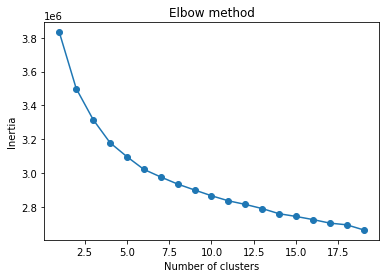

In [74]:
inertias = []
ks = 20

for i in range(1,ks):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(total)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,ks), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [75]:
n_clusters=3
kmeans = KMeans(n_clusters=n_clusters)
kmeans.fit(total)
np.shape(kmeans.labels_)

(1970,)

In [76]:
kmeans_colors=['#fdb84b', '#22a29e','#f15d5b']

Cluster 2 has 313 trials
Cluster 1 has 288 trials
Cluster 0 has 1369 trials


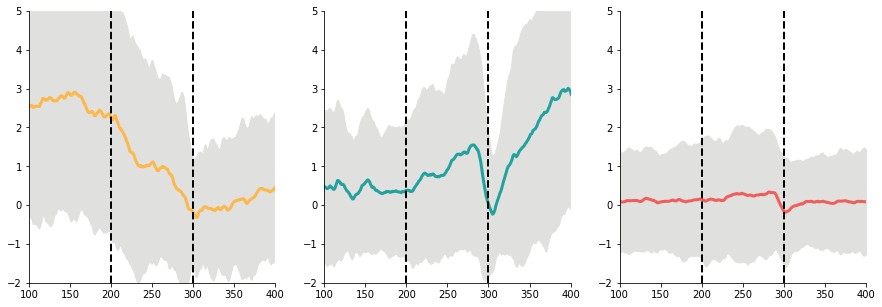

In [77]:
fig,axs=plt.subplots(nrows=1,ncols=n_clusters,figsize=(15,5))
labels=np.asarray(kmeans.labels_)
order=[2,1,0]
for i,o in enumerate(order):
    mean_trace=np.mean(total[labels==o], axis=0)
    std_trace=np.std(total[labels==o], axis=0)
    axs[i].plot(mean_trace.T, color=kmeans_colors[i],lw=3)
    axs[i].fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
    axs[i].axvline(200, linewidth=2, linestyle='--', color='k')
    axs[i].axvline(300, linewidth=2, linestyle='--', color='k')
    axs[i].set_ylim(-2, 5);
    axs[i].set_xlim(100, 400);
#     axs[i].set_xticklabels([])
#     axs[i].set_yticklabels([])
    print(f'Cluster {o} has {np.shape(total[labels==o])[0]} trials')
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
# plt.savefig(os.path.join(save_dir,'k_avg_traces.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

In [78]:
total[labels==0][:,100:150].shape

(1369, 50)

(313,)
(288,)
(1369,)


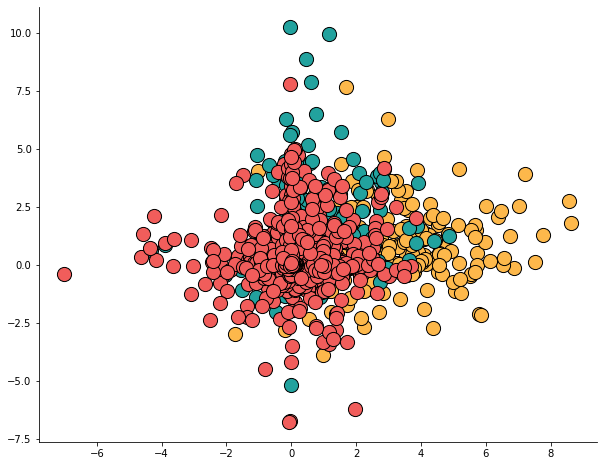

In [79]:
fig,ax=plt.subplots(figsize=(10, 8))
for i,n in enumerate(order):
#     print(key)
    pre=np.mean(total[labels==n][:,150:200], axis=-1)
    print(pre.shape)
    post=np.mean(total[labels==n][:,250:300],axis=-1)
    ax.scatter(pre, post, s=200, color=kmeans_colors[i], label=n,edgecolor='k');
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
#     ax.set_xticklabels([])
#     ax.set_yticklabels([])
# plt.axvline(0,color='k',linestyle='--',lw=2);
# plt.axhline(0,color='k',linestyle='--',lw=2);
# plt.legend();
# plt.xlabel('Avg velocity 2s before stim');
# plt.ylabel('Avg velocity 50ms before end of stim');
# plt.savefig(os.path.join(save_dir,'k_avg_scatter.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,'k_avg_scatter.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

In [80]:
event_times_path=os.path.join(later_dir, 'new_best_5sec_event_times_split_dic.pkl')
with open(event_times_path, 'rb') as file:
    event_times_dic = pickle.load(file)
            

In [81]:
print(event_times_dic.keys())
print(event_times_dic['226'].keys())


dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['inc', 'dec', 'flat', 'non'])


In [82]:
pre_window = 200
post_window = 300
# avg_around = 20
stim_time = 100

In [83]:
def vals_pre_post(loom, dist_loom, val_a, val_b, total_behave_struct, mean=True):
    pre_stim_total=[]
    post_stim_total=[]
    loom_a=loom-dist_loom
    loom_b=loom+dist_loom
    for fly in total_behave_struct:
        for trial in total_behave_struct[fly]:
            if mean:
                pre_stim=np.mean(trial[val_a:loom_a])
                pre_stim_total.append(pre_stim)
                post_stim=np.mean(trial[loom_b:val_b])
                post_stim_total.append(post_stim)
            else:
                pre_stim=trial[val_a:loom_a]
                pre_stim_total.append(pre_stim)
                post_stim=trial[loom_b:val_b]
                post_stim_total.append(post_stim)
    return pre_stim_total, post_stim_total

In [84]:
def plot_trace(behavior_trace, pre_window, post_window, stim_time):
    mean_trace = np.mean(behavior_trace, axis=0)
    sem_trace = scipy.stats.sem(behavior_trace, axis=0)
    
    plt.figure(figsize=(10,10))
    plt.plot(mean_trace,color='k',linewidth=3)
    plt.fill_between(np.arange(len(mean_trace)),mean_trace-sem_trace, mean_trace+sem_trace, color='k',alpha=0.3)
    plt.axvline(pre_window,color='k',linestyle='--',lw=2)
    plt.axvline(pre_window+stim_time,color='k',linestyle='--',lw=2)
    plt.ylim(-1.5, 3);

In [85]:
behavior_colors={
    'inc': '#FC00B9',
    'dec': '#17D4DE',
    'flat': '#000000',
    'non': '#F5F5F5',
    'total': '#F5F5F5',
    'other': '#F5F5F5'
}

In [86]:
total_event_times_dic={}
total_trials={'inc':[],'dec':[],'flat':[],'non':[]}
total_idx={}
total_behavior={'total':[],'dec':[],'inc':[],'flat':[],'non':[]}
behave_lst={}
for fly in total_data_dict:
    total_event_times_dic[fly]={'inc':[],'dec':[],'flat':[],'non':[]}
    total_idx[fly]={'inc':[],'dec':[],'flat':[],'non':[]}
    fly_behavior=total_data_dict[fly]['behavior']
    looms=total_data_dict[fly]['event_times']
    behave_lst[fly]={'total':[],'label':[]}
    for i,trial in enumerate(fly_behavior):
    #     print(np.shape(trial))
        pre=np.mean(trial[150:200])
        post=np.mean(trial[250:300])
        total_behavior['total'].append([pre, post])
        behave_lst[fly]['total'].append([pre, post])
        if pre>-0.1 and pre<0.1 and post>-0.1 and post<0.1:
                total_event_times_dic[fly]['flat'].append(looms[i])
                total_trials['flat'].append(fly_behavior[i])
                total_behavior['flat'].append([pre, post])
                total_idx[fly]['flat'].append(i)
                b='flat'
        elif post>np.abs(pre*2):
                total_event_times_dic[fly]['inc'].append(looms[i])
                total_trials['inc'].append(fly_behavior[i])
                total_behavior['inc'].append([pre, post])
                total_idx[fly]['inc'].append(i)
                b='inc'
        elif post<pre/2:
                total_event_times_dic[fly]['dec'].append(looms[i])
                total_trials['dec'].append(fly_behavior[i])
                total_behavior['dec'].append([pre, post])
                total_idx[fly]['dec'].append(i)
                b='dec'
                
        else:
            total_event_times_dic[fly]['non'].append(looms[i])
            total_trials['non'].append(fly_behavior[i])
            total_behavior['non'].append([pre, post])
            total_idx[fly]['non'].append(i)
            b='non'
        behave_lst[fly]['label'].append(b)
    behave_lst[fly]['label']=np.asarray(behave_lst[fly]['label'])
    behave_lst[fly]['total']=np.asarray(behave_lst[fly]['total'])

In [87]:
for b in total_behavior:
    print(f'{b}: {len(total_behavior[b])}')

total: 1970
dec: 695
inc: 383
flat: 520
non: 372


In [88]:
# file_path=os.path.join(later_dir, 'new_10flies_5sec_event_times_split_dic.pkl')
# with open(file_path, 'wb') as file:
#         pickle.dump(total_event_times_dic, file)

In [89]:
rainbow_color=np.asarray(['#FFFFFF','#EF476F', '#F78C6B', '#FFD166', '#06D6A0','#118AB2','#6A4C93','#6d0d25'])[::-1] #,  '#6d0d25'
cmap_rainbow = matplotlib.colors.LinearSegmentedColormap.from_list('cmap', rainbow_color)

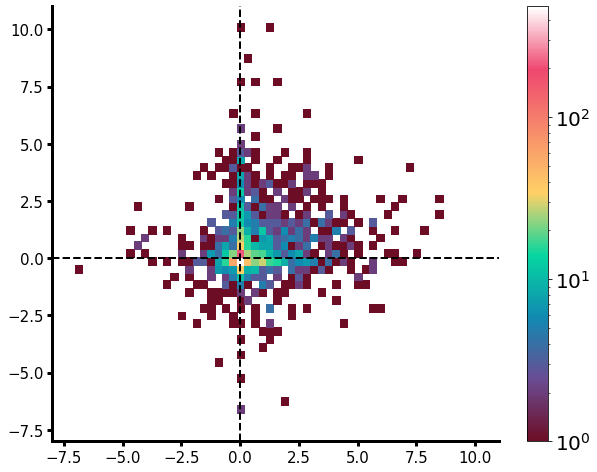

In [90]:
key='total'

fig,ax=plt.subplots(figsize=(10,8))
norm = colors.LogNorm()
plt.hist2d(np.asarray(total_behavior[key])[:,0],np.asarray(total_behavior[key])[:,1],bins=50,norm=norm,cmap=cmap_rainbow, rasterized=True);
ax.set_ylim(-8,11)
ax.set_xlim(-8,11)
# ax.set_ylabel('Rotation, deg/sec')
# ax.set_xlabel('Forward, mm/sec')
# ax.set_xticks([])
# ax.set_yticks([])
ax.axhline(0, linewidth=2, linestyle='--', color='k')
ax.axvline(0, linewidth=2, linestyle='--', color='k')
ax.spines['top'].set_visible(False);
ax.spines['right'].set_visible(False);
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.spines['left'].set_linewidth(3)
ax.spines['bottom'].set_linewidth(3)
ax.tick_params(axis='both', length=5, width=3)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=20)
# plt.savefig(os.path.join(save_dir,f'{key}_2d_hist.png'), dpi=300, bbox_inches='tight');


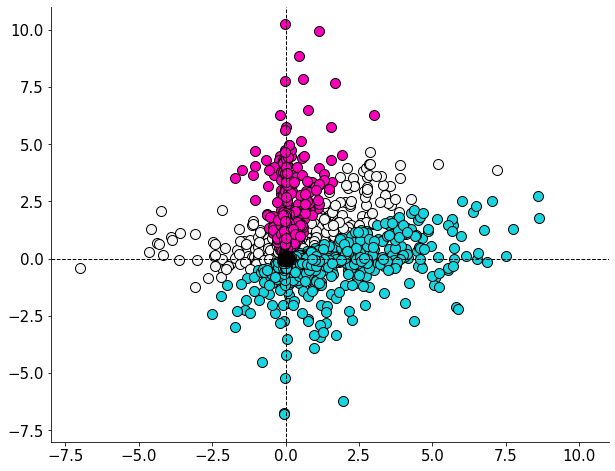

In [91]:
fig,ax=plt.subplots(figsize=(10, 8))
# plt.scatter(total_pre, total_post);
behavior_set=total_behavior
order=['non','inc','dec','flat']
for key in order:
#     print(key)
    ax.scatter(np.asarray(behavior_set[key])[:,0], np.asarray(behavior_set[key])[:,1], s=100,color=behavior_colors[key], edgecolor='k', label=key);
ax.spines['top'].set_visible(False);
ax.spines['right'].set_visible(False);
# ax.set_xticklabels([]);
# ax.set_yticklabels([]);
ax.set_xlim(-8,11)
ax.set_ylim(-8,11)
plt.axvline(0,color='k',linestyle='--',lw=1);
plt.axhline(0,color='k',linestyle='--',lw=1);
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
# plt.legend();
# plt.savefig(os.path.join(save_dir,'total_avg_scatter.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
# plt.savefig(os.path.join(save_dir,f'total_avg_scatter_{order}.png'), dpi=300, bbox_inches='tight', format="png", transparent=True)

In [92]:
np.shape(total_behavior['inc'])
np.asarray(total_behavior['flat'])[:,0].max()


0.09998917072671581

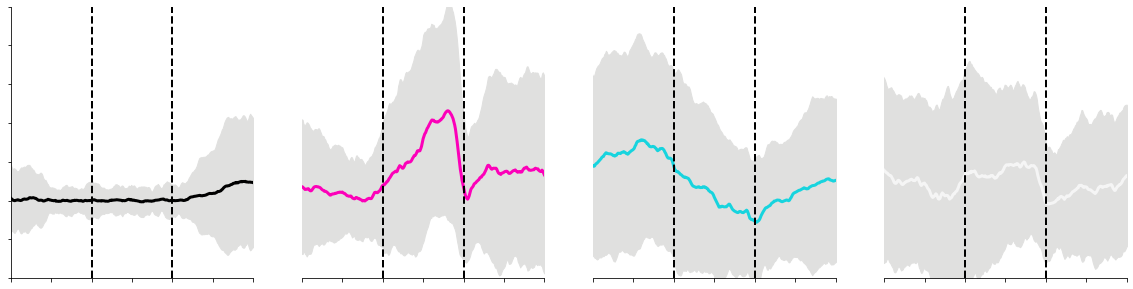

In [93]:
order=['flat','inc','dec','non',]
fig,axs=plt.subplots(nrows=1,ncols=len(order),figsize=(20,5))
for i,be in enumerate(order):
    mean_trace=np.mean(total_trials[be], axis=0)
    std_trace=np.std(total_trials[be], axis=0)
    axs[i].plot(mean_trace, color=behavior_colors[be],lw=3)
    axs[i].fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
    axs[i].axvline(200, linewidth=2, linestyle='--', color='k')
    axs[i].axvline(300, linewidth=2, linestyle='--', color='k')
    axs[i].set_ylim(-2, 5);
    axs[i].set_xlim(100, 400);
    axs[i].set_xticklabels([])
    axs[i].set_yticklabels([])
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    if be!='flat':
        axs[i].spines['left'].set_visible(False)
        axs[i].set_yticks([])
# plt.savefig(os.path.join(save_dir,'total_avg_traces.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
# plt.savefig(os.path.join(save_dir,'total_avg_traces.png'), dpi=300, bbox_inches='tight', format="png", transparent=True)

In [94]:
behave_lst['226']['label'][5:10]
labels,count=np.unique(behave_lst['226']['label'][5:10], return_counts=True)
count

array([4, 1])

In [95]:
%%time
trial_num=np.max(highest_events)
bin_size=10
bins=np.arange(0,trial_num,bin_size)
in_order={'inc':np.zeros_like(bins),'dec':np.zeros_like(bins),'flat':np.zeros_like(bins),'non':np.zeros_like(bins)}
for i in range(len(bins)):
    start=bins[i]
    if i+1<len(bins):
        end=bins[i+1]
    else:
        end=bins[i]+bin_size
    for fly in behave_lst:
        fly_labels=behave_lst[fly]['label'][start:end]
        labels,count=np.unique(fly_labels, return_counts=True)
        for j,label in enumerate(labels):
            in_order[label][i]+=count[j]


CPU times: user 5.11 ms, sys: 2.67 ms, total: 7.78 ms
Wall time: 5.53 ms


In [96]:
in_order['inc'].shape

(20,)

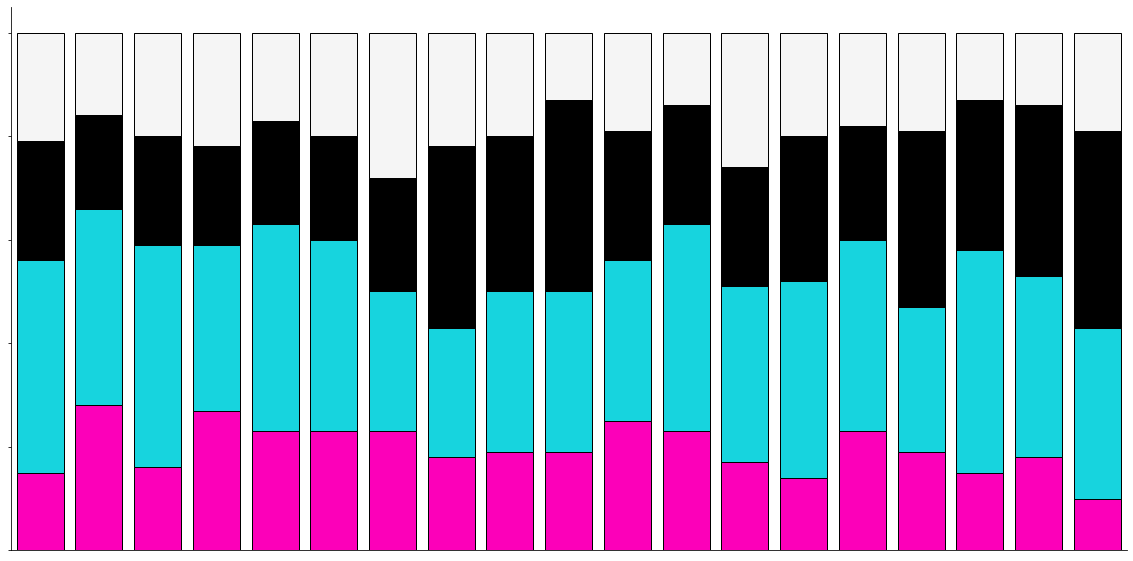

In [97]:
fig, ax = plt.subplots(figsize=(20,10))

labels = list(in_order.keys())
values = list(in_order.values())

# Create plot
x = np.arange(len(values[0]))
bottom = np.zeros(len(values[0]))

for i, (label, value) in enumerate(zip(labels, values)):
    ax.bar(x, value, label=label, bottom=bottom, color=behavior_colors[label],edgecolor='k')
    bottom += value
ax.set_xlim(-0.5,18.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks([])
ax.set_yticklabels([])
# plt.savefig(os.path.join(save_dir,'total_traces_type_bar.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,'total_traces_type_bar.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

plt.show()

In [98]:
trial_count_lst=[]
b_val={'inc':1,'dec':-1,'flat':0,'non':2}
for fly in behave_lst:
    labels=behave_lst[fly]['label'][:least]
    be=np.unique(labels)
    flies=np.full(least,np.nan)
    for b in be:
        flies[labels==b]=b_val[b]
    trial_count_lst.append(flies)
trial_count_lst=np.asarray(trial_count_lst)   

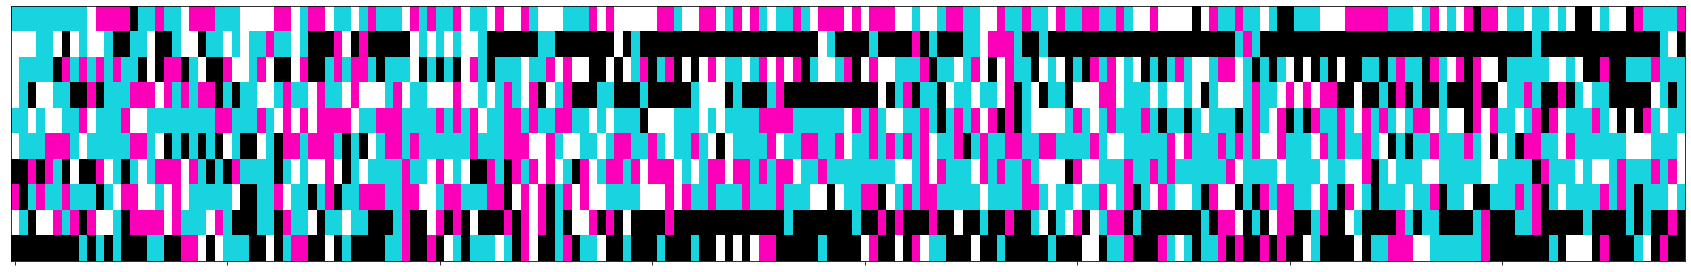

In [99]:
colors=['#17D4DE', 'k', '#FC00B9','w']
cmap=matplotlib.colors.ListedColormap(colors)
fig,ax=plt.subplots(figsize=(30,30))
im=ax.imshow(trial_count_lst, cmap=cmap)
ax.set_yticks([]);
ax.set_xticklabels([]);
ax.set_aspect(3)
ax.tick_params(axis='x', labelsize=40)
# plt.savefig(os.path.join(save_dir,'total_behavior_heatmap.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
# plt.savefig(os.path.join(save_dir,'total_behavior_heatmap.png'), dpi=300, bbox_inches='tight')


In [100]:
behave_lst['226']['label'].shape

(197,)

In [101]:
# Initialize the results dictionary
repeats_sorted = {'inc': {}, 'dec': {}, 'flat': {}, 'non':{}}

# Process each fly separately
for fly in behave_lst:
    fly_data = behave_lst[fly]['label']

    # Process continuous runs of the same value
    i = 0
    while i < len(fly_data):
        if fly_data[i] is None:
            i += 1
            continue

        # Get the current value
        val = fly_data[i]
        name = val

        # Find the length of this run
        run_length = 1
        j = i + 1
        while j < len(fly_data) and fly_data[j] == val and not fly_data[j] is None:
            run_length += 1
            j += 1

        # Record this run in our results
        if run_length not in repeats_sorted[name]:
            repeats_sorted[name][run_length] = 0
        repeats_sorted[name][run_length] += 1

        # Skip ahead to the end of this run
        i = j

In [102]:
np.sum(list(repeats_sorted['dec'].values()))

405

In [103]:
repeats_sorted_percent={}
bes=list(repeats_sorted.keys())
for b in bes:
    sum_total=np.sum(list(repeats_sorted[b].values()))
    repeats_sorted_percent[b]={}
    print(b, sum_total)
    for val in repeats_sorted[b]:
        repeats_sorted_percent[b][val]=(repeats_sorted[b][val]/sum_total)*100

inc 298
dec 405
flat 245
non 286


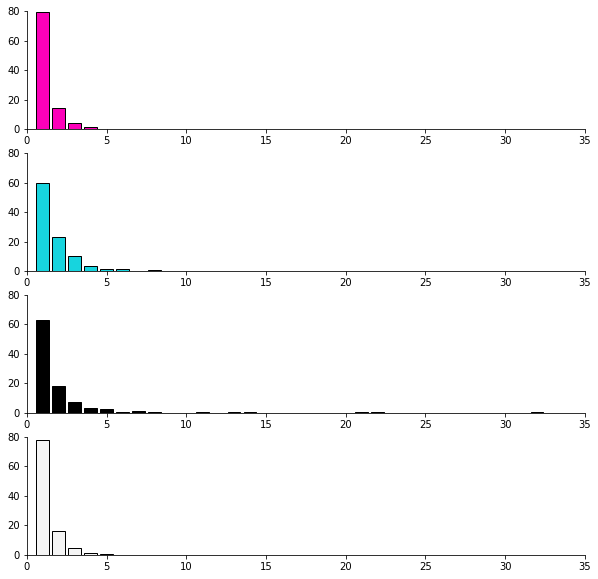

In [104]:

fig,axs = plt.subplots(nrows=4, ncols=1,figsize=(10,10))
ax_count=0

for behave in repeats_sorted:
    sorted_vals=[repeats_sorted_percent[behave][key] for key in repeats_sorted_percent[behave]]
    keys=list(repeats_sorted_percent[behave].keys())

    axs[ax_count].bar(keys,sorted_vals, color=behavior_colors[behave], edgecolor='k')
    axs[ax_count].set_xlim(0,35)
    axs[ax_count].set_ylim(0,80)
    axs[ax_count].spines['top'].set_visible(False)
    axs[ax_count].spines['right'].set_visible(False)
    ax_count+=1
    
    
# plt.savefig(os.path.join(save_dir,'hist_trial_type.png'), dpi=300, bbox_inches='tight')
plt.show()

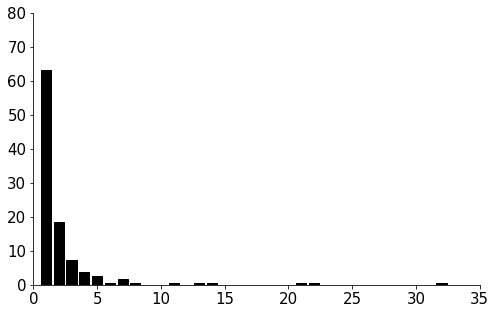

In [105]:

fig,axs = plt.subplots(figsize=(8,5))
# ax_count=0

behave='flat'
sorted_vals=[repeats_sorted_percent[behave][key] for key in repeats_sorted_percent[behave]]
keys=list(repeats_sorted_percent[behave].keys())

axs.bar(keys,sorted_vals, color=behavior_colors[behave], edgecolor='k')
axs.set_xlim(0,35)
axs.set_ylim(0,80)
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
axs.tick_params(axis='x', labelsize=15)
axs.tick_params(axis='y', labelsize=15)
    
    
# plt.savefig(os.path.join(save_dir,f'{behave}_hist_trial_type.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'{behave}_hist_trial_type.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
plt.show()

In [106]:
iterations=100000
null_behaves=[]
for i in range(iterations):
    behaves=list(repeats_sorted.keys())
    null=np.random.choice(behaves, size=least)
    null_behaves.append(null)
null_behaves=np.asarray(null_behaves)

In [107]:
repeats_sorted_null = {'inc': {}, 'dec': {}, 'flat': {}, 'non':{}}

# Process each fly separately
for fly in null_behaves:
    fly_data = np.array(fly)

    # Process continuous runs of the same value
    i = 0
    while i < len(fly_data):
        if fly_data[i] is None:
            i += 1
            continue
        # Get the current value
        val = fly_data[i]
        name = val

        # Find the length of this run
        run_length = 1
        j = i + 1
        while j < len(fly_data) and fly_data[j] == val and not fly_data[j] is None:
            run_length += 1
            j += 1

        # Record this run in our results
        if run_length not in repeats_sorted_null[name]:
            repeats_sorted_null[name][run_length] = 0
        repeats_sorted_null[name][run_length] += 1

        # Skip ahead to the end of this run
        i = j
#         print(i,j)

In [108]:
repeats_sorted_null_percent={}
bes=list(repeats_sorted_null.keys())
for b in bes:
    sum_total=np.sum(list(repeats_sorted_null[b].values()))
    repeats_sorted_null_percent[b]={}
    print(b, sum_total)
    for val in repeats_sorted_null[b]:
        repeats_sorted_null_percent[b][val]=(repeats_sorted_null[b][val]/sum_total)*100

inc 3700542
dec 3697683
flat 3700818
non 3701752


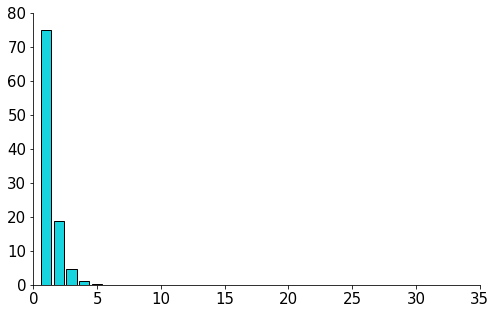

In [109]:
fig,axs = plt.subplots(figsize=(8,5))
# ax_count=0

behave='dec'
sorted_vals=[repeats_sorted_null_percent[behave][key] for key in repeats_sorted_null_percent[behave]]
keys=list(repeats_sorted_null_percent[behave].keys())

axs.bar(keys,sorted_vals, color=behavior_colors[behave], edgecolor='k')
axs.set_xlim(0,35)
axs.set_ylim(0,80)
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
axs.tick_params(axis='x', labelsize=15)
axs.tick_params(axis='y', labelsize=15)
# axs.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
# plt.savefig(os.path.join(save_dir,f'{behave}_hist_trial_type_rand.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
# plt.savefig(os.path.join(save_dir,f'{behave}_hist_trial_type_rand.png'), dpi=300, bbox_inches='tight')


In [110]:
for fly in total_data_dict:
    print(len(total_data_dict[fly]['behavior']))
    print(np.shape(total_data_dict[fly]['event_times']))

197
(197,)
197
(197,)
197
(197,)
197
(197,)
197
(197,)
197
(197,)
197
(197,)
197
(197,)
197
(197,)
197
(197,)


In [111]:
best_event_times_dic={}
best_trials={'inc':[],'dec':[],'flat':[],'non':[]}
best_idx={}
best_behavior={'total':[],'dec':[],'inc':[],'flat':[],'non':[]}
best_behave_lst={}
for fly in total_data_dict:
    best_event_times_dic[fly]={'inc':[],'dec':[],'flat':[],'non':[]}
    best_idx[fly]={'inc':[],'dec':[],'flat':[],'non':[]}
    fly_behavior=total_data_dict[fly]['behavior']
    amt=len(fly_behavior)
    looms=total_data_dict[fly]['event_times'][:amt]
    best_behave_lst[fly]={'total':np.zeros((amt,2)),'label':np.full(amt,'other')}
    for i,trial in enumerate(fly_behavior):
        pre=np.mean(trial[150:200])
        post=np.mean(trial[250:300])
        best_behavior['total'].append([pre, post])
        if pre>-1 and pre <0.1 and post>1 and post>np.abs(pre*2):
            best_event_times_dic[fly]['inc'].append(looms[i])
            best_trials['inc'].append(fly_behavior[i])
            best_behavior['inc'].append([pre, post])
            best_idx[fly]['inc'].append(i)
            b='inc'
        elif pre>1 and post<0.1 and post>-1 and post<pre/2:
            best_event_times_dic[fly]['dec'].append(looms[i])
            best_trials['dec'].append(fly_behavior[i])
            best_behavior['dec'].append([pre, post])
            best_idx[fly]['dec'].append(i)
            b='dec'
        else:
            b='other'
        best_behave_lst[fly]['label'][i]=b
        best_behave_lst[fly]['total'][i]=[pre, post]

In [112]:
inc_min=np.min(best_behavior['inc'])
dec_min=np.min(best_behavior['dec'])
for fly in total_data_dict:
    fly_behavior=total_data_dict[fly]['behavior']
    amt=len(fly_behavior)
    looms=np.asarray(total_data_dict[fly]['event_times'])[:amt]
    already=np.hstack([best_idx[fly]['inc'],best_idx[fly]['dec']])
    to_use=np.arange(len(looms))[~np.isin(np.arange(len(looms)),already)]
    for i in to_use:
        trial=total_data_dict[fly]['behavior'][i,:]
        pre=np.mean(trial[150:200])
        post=np.mean(trial[250:300])
        if pre>-0.1 and pre<0.1 and post>-0.1 and post<0.1:
            best_event_times_dic[fly]['flat'].append(looms[i])
            best_trials['flat'].append(fly_behavior[i])
            best_behavior['flat'].append([pre, post])
            best_idx[fly]['flat'].append(i)
            b='flat'
#         elif pre>inc_min and pre<0.1 and post>dec_min and post<0.1:
#             best_event_times_dic[fly]['non'].append(looms[i])
#             best_trials['non'].append(fly_behavior[i])
#             best_behavior['non'].append([pre, post])
#             best_idx[fly]['non'].append(i)
#             b='non'
        else:
            b='other'
        best_behave_lst[fly]['label'][i]=b
        best_behave_lst[fly]['total'][i]=[pre, post]

In [113]:
for b in best_behavior:
    print(f'{b}: {len(best_behavior[b])}')

total: 1970
dec: 143
inc: 132
flat: 520
non: 0


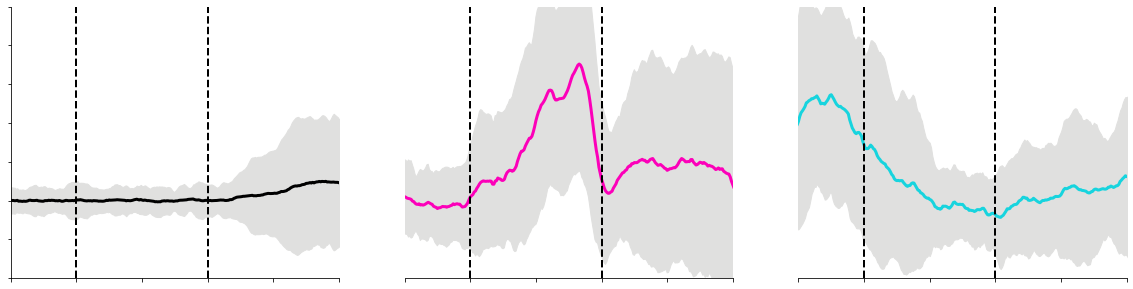

In [114]:
order=[ 'flat','inc', 'dec',]
fig,axs=plt.subplots(nrows=1,ncols=len(order),figsize=(20,5))
for i,be in enumerate(order):
    mean_trace=np.mean(best_trials[be], axis=0)
    std_trace=np.std(best_trials[be], axis=0)
    axs[i].plot(mean_trace, color=behavior_colors[be],lw=3)
    axs[i].fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
    axs[i].axvline(200, linewidth=2, linestyle='--', color='k')
    axs[i].axvline(300, linewidth=2, linestyle='--', color='k')
    axs[i].set_ylim(-2, 5);
    axs[i].set_xlim(150, 400);
    axs[i].set_xticklabels([])
    axs[i].set_yticklabels([])
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    if be!='flat':
        axs[i].spines['left'].set_visible(False)
        axs[i].set_yticks([])
# plt.savefig(os.path.join(save_dir,'best_avg_traces.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
# plt.savefig(os.path.join(save_dir,'best_avg_traces.png'), dpi=300, bbox_inches='tight', format="png", transparent=True)

In [115]:
best_behavior.keys()

dict_keys(['total', 'dec', 'inc', 'flat', 'non'])

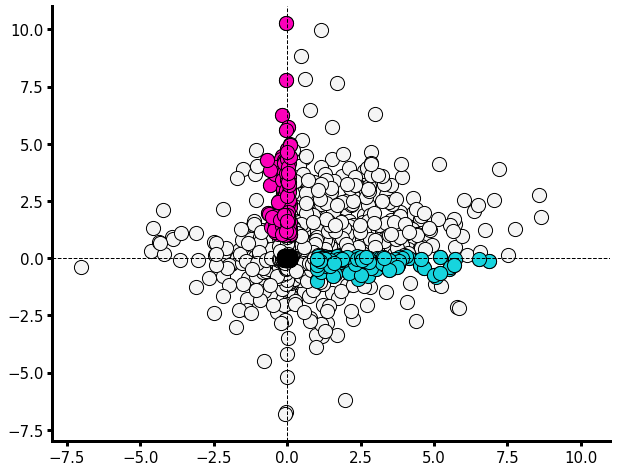

In [116]:
fig,ax=plt.subplots(figsize=(10, 8))
# plt.scatter(total_pre, total_post);
behavior_set=best_behavior
order=['total','inc','dec','flat']#,'inc','dec','flat']
for key in order:
#     print(key)
    ax.scatter(np.asarray(behavior_set[key])[:,0], np.asarray(behavior_set[key])[:,1], s=200,color=behavior_colors[key], edgecolor='k', label=key);
ax.set_rasterized(True)
ax.spines['top'].set_visible(False);
ax.spines['right'].set_visible(False);
ax.set_xlim(-8,11)
ax.set_ylim(-8,11)
# ax.set_xticklabels([]);
# ax.set_yticklabels([]);
plt.axvline(0,color='k',linestyle='--',lw=1);
plt.axhline(0,color='k',linestyle='--',lw=1);
ax.spines['left'].set_linewidth(3)
ax.spines['bottom'].set_linewidth(3)
ax.tick_params(axis='both', length=5, width=3)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
# plt.legend();
# plt.savefig(os.path.join(save_dir,'best_avg_scatter.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
# plt.savefig(os.path.join(save_dir,f'best_avg_scatter_{order}.png'), dpi=300, bbox_inches='tight', format="png", transparent=True)

In [117]:
best_trial_count_lst=[]
b_val={'inc':1,'dec':-1,'flat':0, 'other':-2}
for fly in best_behave_lst:
    labels=best_behave_lst[fly]['label'][:least]
    be=np.unique(labels)
    flies=np.full(least,np.nan)
    for b in be:
#         print(b,b_val[b])
        flies[labels==b]=b_val[b]
    best_trial_count_lst.append(flies)
best_trial_count_lst=np.asarray(best_trial_count_lst)   

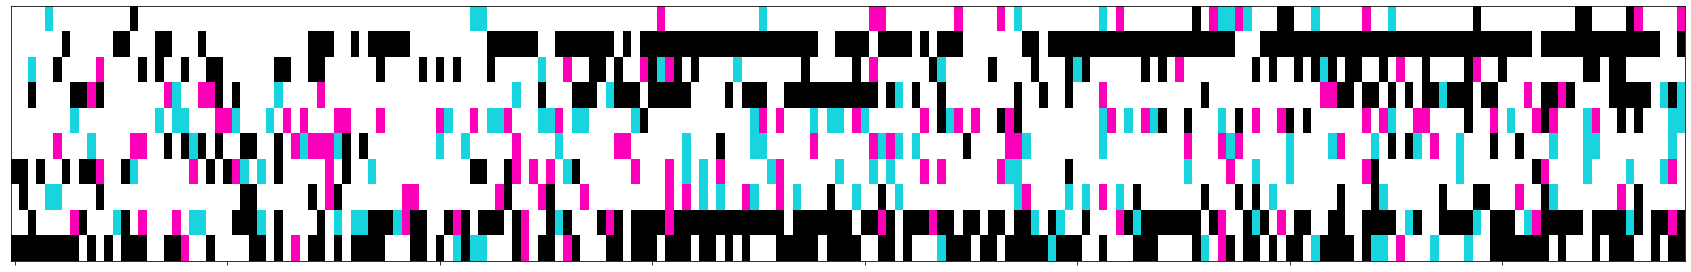

In [118]:
colors=['#FC00B9','k','#17D4DE','w'][::-1]
cmap=matplotlib.colors.ListedColormap(colors)
fig,ax=plt.subplots(figsize=(30,30))
im=ax.imshow(best_trial_count_lst, cmap=cmap)
ax.set_yticks([]);
ax.set_xticklabels([]);
ax.set_aspect(3)
ax.tick_params(axis='x', labelsize=40)
# plt.savefig(os.path.join(save_dir,'best_behavior_heatmap.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
# plt.savefig(os.path.join(save_dir,'best_behavior_heatmap.png'), dpi=300, bbox_inches='tight', format="png", transparent=True)

In [119]:
%%time
trial_num=np.max(highest_events)
bin_size=10
bins=np.arange(0,trial_num,bin_size)
in_order={'inc':np.zeros_like(bins),'dec':np.zeros_like(bins),'flat':np.zeros_like(bins), 'other':np.zeros_like(bins)}
for i in range(len(bins)):
    start=bins[i]
    if i+1<len(bins):
        end=bins[i+1]
    else:
        end=bins[i]+bin_size
    for fly in best_behave_lst:
        fly_labels=best_behave_lst[fly]['label'][start:end]
        labels,count=np.unique(fly_labels, return_counts=True)
        for j,label in enumerate(labels):
            if label in list(in_order.keys()):
                in_order[label][i]+=count[j]

CPU times: user 5.8 ms, sys: 1.88 ms, total: 7.68 ms
Wall time: 5.64 ms


In [120]:
shape=np.shape(list(in_order.values()))
totals=np.zeros(shape[1])
for i in range(shape[1]):
    total_count=0
    for j,be in enumerate(in_order):
        total_count+=in_order[be][i]
    totals[i]=total_count

In [121]:
for i,be in enumerate(in_order):
    in_order[be]=(in_order[be]/totals)*100

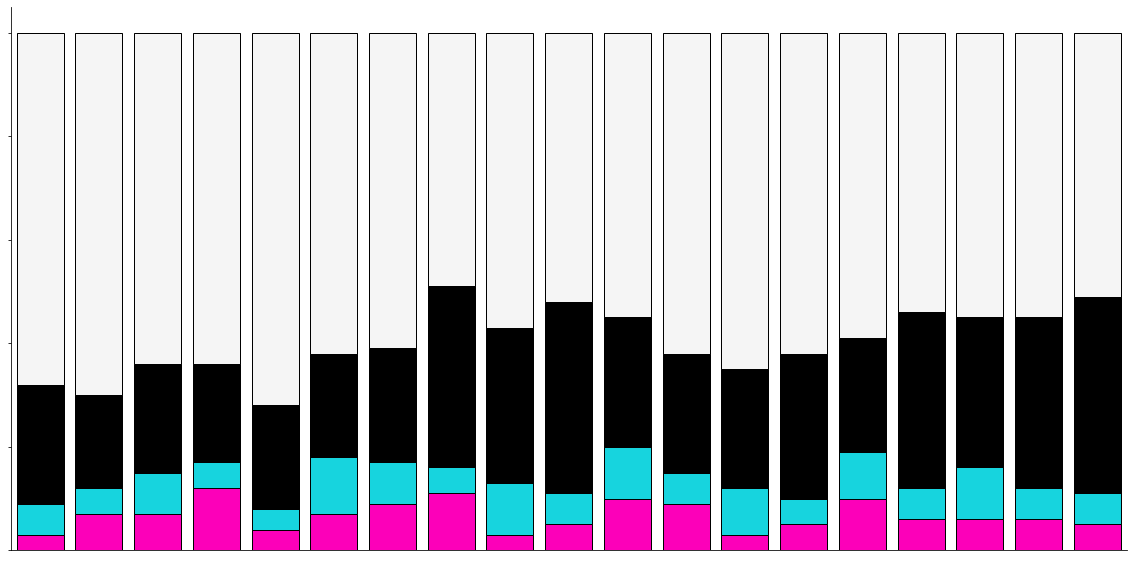

In [122]:
fig, ax = plt.subplots(figsize=(20,10))

labels = list(in_order.keys())
values = list(in_order.values())

# Create plot
x = np.arange(len(values[0]))
bottom = np.zeros(len(values[0]))

for i, (label, value) in enumerate(zip(labels, values)):
    ax.bar(x, value, label=label, bottom=bottom, color=behavior_colors[label],edgecolor='k')
    bottom += value
ax.set_xlim(-0.5,18.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks([])
ax.set_yticklabels([])
# plt.savefig(os.path.join(save_dir,'best_traces_type_bar.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,'best_traces_type_bar.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

plt.show()